# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [39]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [41]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [42]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [43]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [44]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [45]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [46]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [47]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [48]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [49]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
• city (11.7% nulos): imputar con "Unknown" o investigar la causa para evitar perder registros.

• churn_date (88.3% nulos): mantener los nulos, ya que probablemente representan clientes activos y no un problema de calidad.

• date (0.13% nulos): eliminar o revisar manualmente los pocos registros afectados.

• duration (55.2% nulos): analizar la relación con el tipo de uso antes de imputar, ya que los nulos podrían ser válidos.

• length (44.7% nulos): investigar su dependencia con la variable type para determinar si los faltantes son esperados o requieren tratamiento.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [50]:
# explorar columnas numéricas de users
users[["user_id", "age"]].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id' parece funcionar como identificador único. No se observan valores anómalos en la exploración inicial.
- La columna `age' presenta un valor mínimo de -999, lo que indica la presencia de un valor sentinel utilizado para representar datos faltantes o inválidos. Este valor deberá convertirse a NaN antes del análisis.

In [51]:
# explorar columnas numéricas de usage
usage[["id", "user_id"]].describe()

,id,user_id
count,40000.00000,40000.000000
mean,20000.50000,12002.405975
std,11547.14972,1157.279564
min,1.00000,10000.000000
25%,10000.75000,10996.000000
50%,20000.50000,12013.000000
75%,30000.25000,13005.000000
max,40000.00000,13999.000000


- Las columnas (user_id e id) funcionan como identificadores y no muestran anomalías evidentes. Se recomienda validar su unicidad y mantenerlas sin modificaciones.

In [52]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].value_counts(dropna=False))


Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna city presenta 469 valores nulos y 96 registros con el valor "?", el cual parece utilizarse como sentinel para indicar información desconocida. Se recomienda unificar "?" por NaN antes del análisis.
- La columna plan presenta únicamente las categorías esperadas (Basic y Premium) y no muestra valores anómalos.

In [53]:
# explorar columna categórica de usage
usage[["type"]].describe()

,type
count,40000
unique,2
top,text
freq,22092


- La columna type contiene únicamente dos categorías distintas. No se observan valores faltantes ni categorías inesperadas en la exploración inicial.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
-Se identificó un valor sentinel (-999) en la columna (age). Se recomienda reemplazarlo por NaN antes de realizar análisis o segmentaciones.
-La columna (city) presenta 469 valores nulos y 96 registros con el valor "?", el cual probablemente representa información faltante. Se recomienda unificar "?" a NaN y evaluar una estrategia de imputación.
-Las columnas (user_id e id) funcionan como identificadores y no muestran anomalías evidentes. Se recomienda validar su unicidad y mantenerlas sin modificaciones.
-La columna (plan) contiene únicamente las categorías esperadas (Basic y Premium). No se requieren acciones de limpieza adicionales.
-La columna (type) contiene dos categorías válidas y no presenta problemas aparentes de calidad. Se recomienda únicamente verificar que ambas categorías correspondan a valores esperados del negocio. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [54]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors = "coerce")

In [55]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage["date"], errors = "coerce")

In [56]:
# Revisar los años presentes en `reg_date` de users
print(users["reg_date"].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En reg_date se observan registros de los años 2022, 2023 y 2024, los cuales son consistentes con el periodo analizado. Sin embargo, se identificaron 40 registros correspondientes al año 2026, un año futuro respecto al alcance de los datos. Se recomienda revisar estos registros y corregirlos o excluirlos antes del análisis.

In [57]:
# Revisar los años presentes en `date` de usage
print(usage["date"].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64



En date todos los registros corresponden al año 2024. No se identifican fechas futuras ni valores fuera de rango, por lo que no se requieren acciones correctivas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- Sí. En la columna reg_date se identificaron 40 registros correspondientes al año 2026, el cual se encuentra fuera del rango esperado del dataset. En la columna date no se detectaron años fuera de rango.
- ¿Qué harías con ellas?
- Se recomienda investigar los registros del año 2026 para validar si se trata de errores de captura. Dependiendo del contexto del negocio, estos registros podrían corregirse, marcarse como valores faltantes o excluirse del análisis para evitar sesgos en los resultados.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [58]:
# Reemplazar -999 por la mediana de age

users['age'] = users['age'].replace(-999, pd.NA)
age_mediana = users["age"].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [59]:
# Reemplazar ? por NA en city

users["city"] = users["city"].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [60]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios

users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [61]:
# Verificación MAR en usage (Missing At Random) para duration

print(
    usage.groupby("type")["duration"]
         .apply(lambda x: x.isna().mean())
)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [62]:
# Verificación MAR en usage (Missing At Random) para length


print(
    usage.groupby("type")["length"]
         .apply(lambda x: x.isna().mean())
)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los valores faltantes en duration y length dependen claramente de la variable type. La columna duration presenta valores nulos principalmente para registros de tipo text, mientras que la columna length presenta valores nulos principalmente para registros de tipo call.

Este comportamiento indica que los valores faltantes siguen un patrón relacionado con el tipo de uso registrado y no corresponden a errores de captura. Por lo tanto, los nulos pueden considerarse MAR y se recomienda conservarlos sin imputación, ya que contienen información relevante del negocio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [63]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (usage.groupby("user_id").agg({"is_text": "sum", "is_call": "sum", "duration": "sum"}).reset_index())

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [64]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns = {"is_text": "cant_mensajes", "is_call": "cant_llamadas", "duration": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [65]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on = "user_id", how = "left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [66]:
# Resumen estadístico de las columnas numéricas

user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [67]:
# Distribución porcentual del tipo de plan

user_profile["plan"].value_counts(normalize = True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

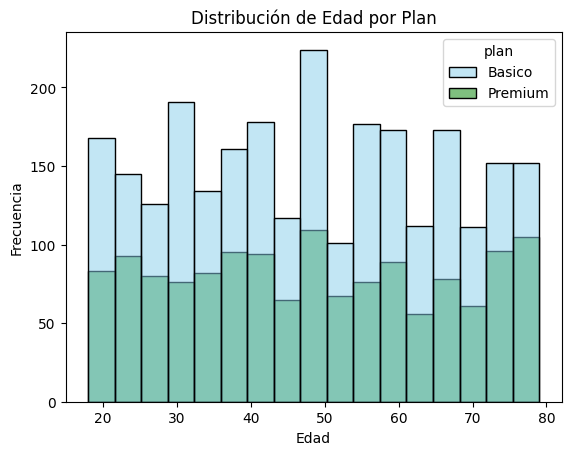

In [68]:
# Histograma para visualizar la edad (age)
sns.histplot(data = user_profile, x="age", hue="plan", palette= ["skyblue", "green"])

plt.title("Distribución de Edad por Plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución de edad parece relativamente equilibrada entre los planes Basic y Premium. No se observan diferencias importantes en la composición etaria de los usuarios. La distribución es aproximadamente simétrica.

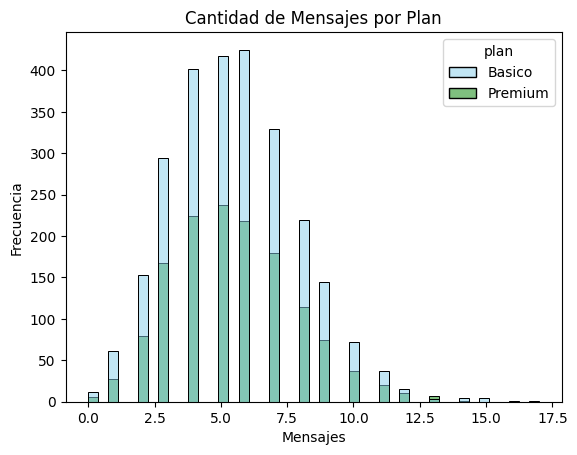

In [69]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data= user_profile, x="cant_mensajes", hue="plan", palette=["skyblue", "green"])

plt.title("Cantidad de Mensajes por Plan")
plt.xlabel("Mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución de mensajes es similar entre los usuarios de los planes Basic y Premium. La mayor parte de los usuarios se concentra en niveles bajos y medios de uso, mientras que un grupo reducido presenta una cantidad mayor de mensajes. La distribución muestra un ligero sesgo hacia la derecha.

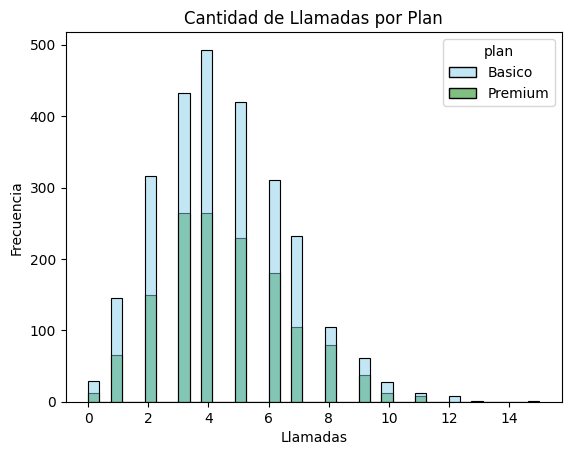

In [70]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data = user_profile, x="cant_llamadas", hue="plan", palette=["skyblue", "green"])

plt.title("Cantidad de Llamadas por Plan")
plt.xlabel("Llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- Los usuarios de ambos planes presentan patrones de llamadas similares. La mayoría se concentra en niveles moderados de uso, aunque existen algunos usuarios con una cantidad de llamadas considerablemente superior al resto. La distribución presenta sesgo positivo (hacia la derecha).

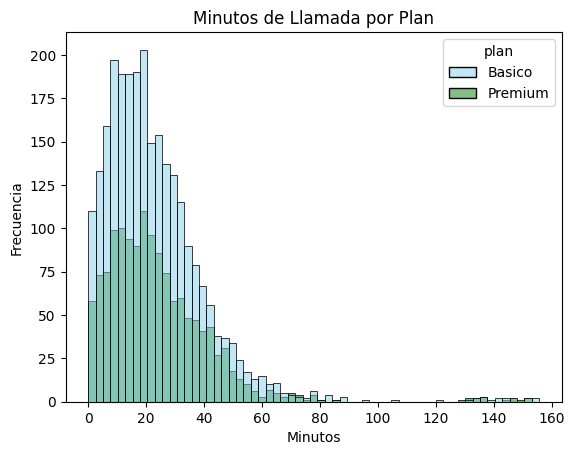

In [71]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data = user_profile, x="cant_minutos_llamada", hue="plan", palette=["skyblue", "green"])

plt.title("Minutos de Llamada por Plan")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución de minutos de llamada presenta un claro sesgo hacia la derecha, ya que la mayoría de los usuarios concentra un menor consumo de minutos mientras que un grupo reducido acumula consumos significativamente más altos. Los usuarios de los planes Basic y Premium muestran patrones similares de comportamiento, aunque se observan algunos usuarios con valores extremos que podrían considerarse potenciales outliers.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

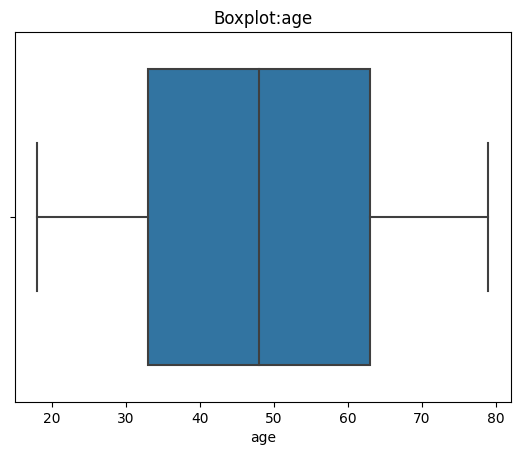

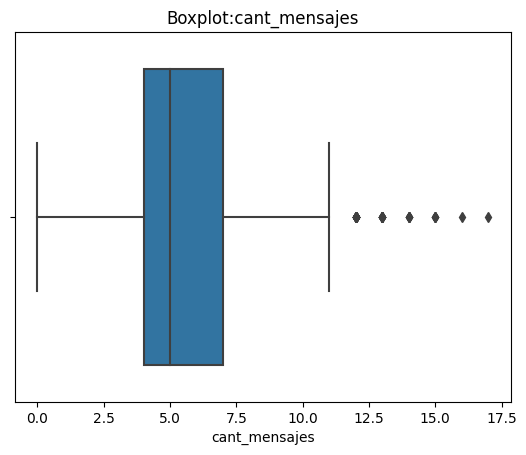

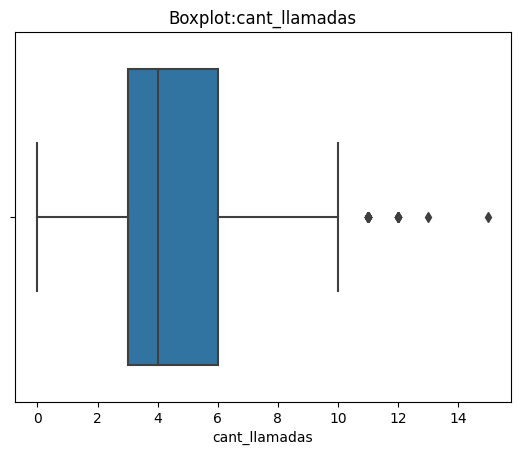

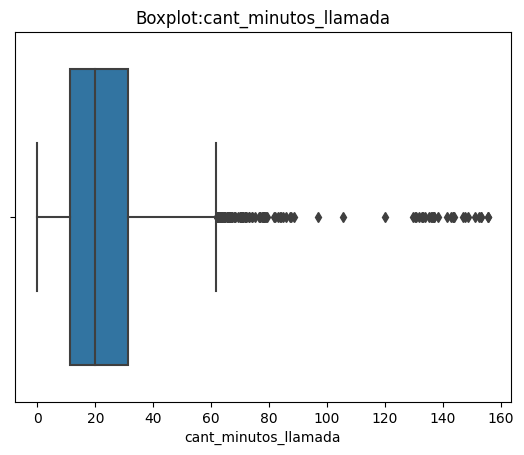

In [72]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot:{col}')
    plt.show()

💡Insights: 
- Age: No se observan outliers en la variable age. La distribución se encuentra dentro de rangos esperados y no presenta valores extremos después de la limpieza realizada.
- cant_mensajes: Se observan algunos outliers en la parte superior de la distribución. Estos valores representan usuarios con una cantidad de mensajes superior al comportamiento típico del resto de los usuarios.
- cant_llamadas: Se identifican algunos outliers en la cola superior de la distribución. Estos registros corresponden a usuarios con un volumen de llamadas mayor al observado en la mayoría de la población.
- cant_minutos_llamada: Se observa la mayor cantidad de outliers en esta variable. Existen usuarios con consumos de minutos significativamente superiores al comportamiento central de la distribución.

In [73]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]

for col in columnas_limites:

    q1= user_profile[col].quantile(0.25)
    q3= user_profile[col].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 - 1.5 * iqr

    print(f"\n{col}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")
    print(f"Máximo observado: {user_profile[col].max()}")


cant_mensajes
Límite inferior: -0.5
Límite superior: 2.5
Máximo observado: 17.0

cant_llamadas
Límite inferior: -1.5
Límite superior: 1.5
Máximo observado: 15.0

cant_minutos_llamada
Límite inferior: -19.322500000000005
Límite superior: 0.9724999999999966
Máximo observado: 155.69


In [74]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- Se identifican valores por encima del límite superior del método IQR. Sin embargo, la diferencia entre el límite superior y el máximo observado no es extrema, por lo que estos registros pueden representar usuarios con un comportamiento de uso intensivo. Se recomienda mantener los outliers para preservar información relevante del negocio.
- cant_llamadas: mantener o no outliers, porqué?
-La variable presenta algunos valores por encima del límite superior calculado mediante IQR. Estos registros parecen corresponder a usuarios con una frecuencia de llamadas superior al promedio y no a errores de captura. Se recomienda conservar los outliers.
- cant_minutos_llamada: mantener o no outliers, porqué?
- Se observan múltiples valores por encima del límite superior del método IQR. Aunque la diferencia entre el límite superior y el máximo observado es considerable, estos valores son consistentes con usuarios de alto consumo. Debido a que la variable representa comportamiento real de uso, se recomienda mantener los outliers para no perder información relevante.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [82]:
# Crear columna grupo_uso

def clasificar_uso(row):

    if row["cant_llamadas"] < 5 and row["cant_mensajes"] < 5:
        return "Bajo uso"

    elif row["cant_llamadas"] < 10 and row["cant_mensajes"] < 10:
        return "Uso medio"

    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1)

In [83]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [84]:
# Crear columna grupo_edad
# Crear columna grupo_edad

def clasificar_edad(row):

    if row["age"] < 30:
        return "Joven"

    elif row["age"] < 60:
        return "Adulto"

    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(clasificar_edad, axis=1)

In [85]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

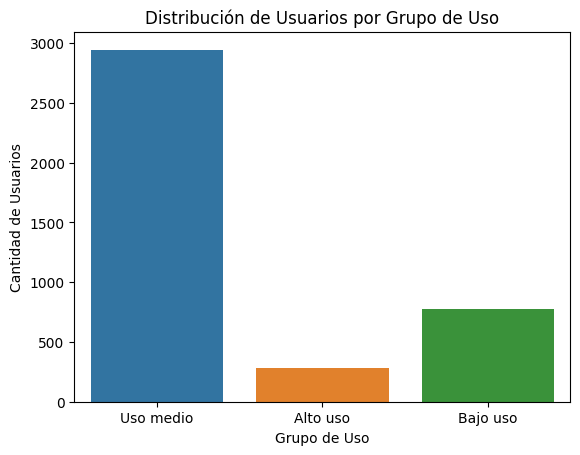

In [86]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x="grupo_uso")

plt.title("Distribución de Usuarios por Grupo de Uso")
plt.xlabel("Grupo de Uso")
plt.ylabel("Cantidad de Usuarios")

plt.show()

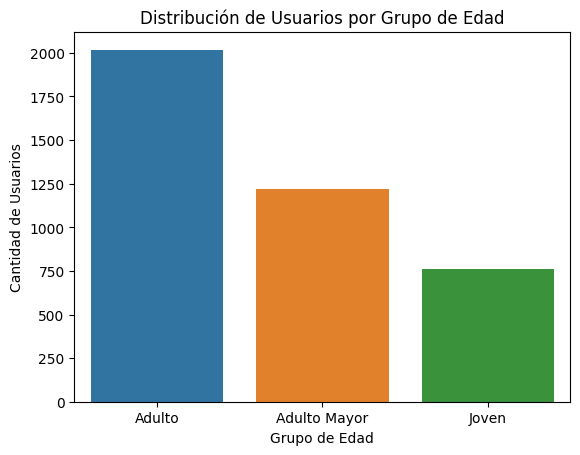

In [87]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x="grupo_edad")

plt.title("Distribución de Usuarios por Grupo de Edad")
plt.xlabel("Grupo de Edad")
plt.ylabel("Cantidad de Usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Se identificaron varios problemas de calidad de datos:

-La columna age contenía el valor sentinel -999, utilizado para representar edades desconocidas o inválidas.
-La columna city presentaba 469 valores nulos y 96 registros con el valor "?", considerado un valor sentinel para datos faltantes.
-La columna reg_date contenía 40 registros del año 2026, considerados fechas fuera de rango debido a que el análisis contempla información hasta 2024.
-Las columnas duration y length presentaban valores nulos, pero se comprobó que estos dependían del tipo de registro (call o text), por lo que corresponden a un patrón MAR y no a errores de captura.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Se identificaron dos tipos de segmentación:
Por edad

Joven
Adulto
Adulto Mayor

La mayor concentración de clientes se encuentra en el segmento de Adultos, representando la base principal de usuarios de ConectaTel.
Por nivel de uso

Bajo uso
Uso medio
Alto uso

La mayoría de los clientes presenta patrones de consumo moderados, mientras que un grupo reducido concentra niveles de uso significativamente más altos.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

El segmento de Alto uso parece ser el más valioso para la compañía.
Estos usuarios registran mayores cantidades de llamadas, mensajes y minutos consumidos, lo que los convierte en candidatos ideales para:

-planes Premium
-programas de fidelización
-campañas de retención
-ofertas de servicios adicionales

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

Se identificaron outliers en:

-cant_mensajes
-cant_llamadas
-cant_minutos_llamada

El método IQR confirmó la presencia de usuarios cuyos niveles de consumo superan significativamente el comportamiento promedio.
Estos valores no parecen errores de captura, sino usuarios con patrones de consumo intensivo. Para el negocio representan clientes de alto valor y oportunidades de monetización.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

-Crear beneficios específicos para usuarios de alto consumo.
-Desarrollar estrategias de migración hacia planes Premium.
-Diseñar ofertas diferenciadas según grupos de edad.
-Implementar monitoreo continuo de calidad de datos para prevenir errores de captura.
-Analizar de forma específica a los usuarios con consumos extremos para identificar oportunidades de crecimiento y retención.

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Durante la etapa de limpieza se identificaron valores sentinel en las columnas age y city, además de registros con fechas futuras en reg_date. También se detectaron valores faltantes en duration y length, los cuales fueron clasificados como MAR debido a su dependencia con la variable type. Se aplicaron las correcciones necesarias para garantizar la calidad del análisis.

🔍 **Segmentos por Edad**

Los clientes fueron clasificados en tres grupos: Jóvenes, Adultos y Adultos Mayores. El segmento Adulto concentra la mayor parte de los usuarios, convirtiéndose en el principal mercado objetivo para ConectaTel. Los grupos Jóvenes y Adultos Mayores representan oportunidades para desarrollar ofertas más especializadas.

📊 **Segmentos por Nivel de Uso**

Los usuarios fueron agrupados en categorías de Bajo uso, Uso medio y Alto uso. Se observó que la mayoría presenta consumos moderados, mientras que un grupo reducido registra niveles significativamente superiores de llamadas, mensajes y minutos consumidos.

➡️ Esto sugiere que ...

Las variables de uso presentan distribuciones sesgadas hacia la derecha, indicando que la mayoría de los clientes tiene consumos moderados y que existe un grupo reducido con consumos elevados. Los outliers identificados fueron conservados debido a que representan comportamientos reales de clientes y no errores de calidad de datos.

💡 **Recomendaciones**

 Se recomienda fortalecer la oferta dirigida a usuarios de alto consumo mediante beneficios exclusivos, programas de fidelización y opciones Premium. Asimismo, es conveniente diseñar estrategias comerciales diferenciadas por grupo de edad y mantener controles de calidad sobre los datos para mejorar la confiabilidad de futuros análisis. El monitoreo continuo de los usuarios con consumos extremos permitirá identificar oportunidades de crecimiento y maximizar el valor generado por los clientes más activos.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://robertocuevas-14.github.io/jose-roberto-data-bi-portfolio/